# Segmentation par K-means — Évaluation complète sur ISIC 2016

**Objectif** : Implémenter et évaluer rigoureusement la segmentation non supervisée par K-means (K=2) sur les 900 images dermoscopiques du dataset ISIC 2016, afin de :
1. Établir une **baseline quantitative** (DSC, IoU, Accuracy, Precision, Recall)
2. **Diagnostiquer et caractériser l'effet de loupe** (vignettage)
3. Comparer plusieurs **variantes** (espaces colorimétriques, ajout de coordonnées spatiales, pré-détection du vignettage)
4. **Analyser les performances par sous-groupes** (taille de lésion, contraste)
5. Produire les **visualisations qualitatives** pour le mémoire

---

In [4]:
import numpy as np
import os
import warnings
from pathlib import Path
from PIL import Image
from sklearn.cluster import KMeans
from scipy import ndimage
from skimage.measure import label, regionprops
from skimage import color
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

# ── Chemins ──
BASE = Path(".").resolve()
IMG_DIR = BASE / "dataset_ISIC" / "ISBI2016_ISIC_Part1_Training_Data"
MASK_DIR = BASE / "dataset_ISIC" / "ISBI2016_ISIC_Part1_Training_GroundTruth"

img_paths = sorted(IMG_DIR.glob("*.jpg"))
mask_paths = sorted(MASK_DIR.glob("*.png"))
N = len(img_paths)
print(f"Images : {N} | Masques : {len(mask_paths)}")

# ── Fonctions utilitaires ──
def load_img(path):
    return np.array(Image.open(path).convert("RGB"))

def load_mask(path):
    m = np.array(Image.open(path).convert("L"))
    return (m > 127).astype(np.uint8)

def dice(y_true, y_pred):
    inter = np.sum(y_true * y_pred)
    denom = np.sum(y_true) + np.sum(y_pred)
    return 2.0 * inter / denom if denom > 0 else 1.0

def iou(y_true, y_pred):
    inter = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - inter
    return inter / union if union > 0 else 1.0

def pixel_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision_score(y_true, y_pred):
    tp = np.sum(y_true * y_pred)
    fp = np.sum((1 - y_true) * y_pred)
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score(y_true, y_pred):
    tp = np.sum(y_true * y_pred)
    fn = np.sum(y_true * (1 - y_pred))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def keep_largest_component(mask_binary):
    """Post-traitement : ne conserve que la plus grande composante connexe."""
    labeled, n = ndimage.label(mask_binary)
    if n <= 1:
        return mask_binary
    sizes = ndimage.sum(mask_binary, labeled, range(1, n + 1))
    largest = np.argmax(sizes) + 1
    return (labeled == largest).astype(np.uint8)

def compute_all_metrics(gt, pred):
    return {
        "dice": dice(gt, pred),
        "iou": iou(gt, pred),
        "accuracy": pixel_accuracy(gt, pred),
        "precision": precision_score(gt, pred),
        "recall": recall_score(gt, pred),
    }

print("Fonctions chargées.")

Images : 900 | Masques : 900
Fonctions chargées.


## 1. Implémentation des variantes de segmentation K-means

On implémente **quatre variantes** du K-means pour comparer systématiquement :

| Variante | Espace de caractéristiques | Dimension |
|----------|---------------------------|-----------|
| **RGB** | $(R, G, B)$ | 3 |
| **RGB + coordonnées spatiales** | $(R, G, B, \alpha \cdot x/W, \alpha \cdot y/H)$ | 5 |
| **LAB** | $(L^*, a^*, b^*)$ | 3 |
| **HSV** | $(H, S, V)$ | 3 |

Pour chaque variante, le protocole est identique :
- $K = 2$ clusters (lésion vs. fond)
- Initialisation $K$-means++ , `n_init=10`
- Le cluster le plus sombre (en niveaux de gris) est assigné à la classe « lésion »
- Post-traitement : conservation de la plus grande composante connexe

In [5]:
# ═══════════════════════════════════════════════════════════════
# Fonctions de segmentation K-means — 4 variantes
# ═══════════════════════════════════════════════════════════════

def _assign_clusters(img_rgb, labels_2d, kmeans):
    """Assigne le cluster le plus sombre à 'lésion' (1), l'autre à 'fond' (0)."""
    gray = 0.299 * img_rgb[..., 0] + 0.587 * img_rgb[..., 1] + 0.114 * img_rgb[..., 2]
    mean_gray_per_cluster = [gray[labels_2d == k].mean() for k in range(2)]
    dark_cluster = int(np.argmin(mean_gray_per_cluster))
    mask = (labels_2d == dark_cluster).astype(np.uint8)
    return keep_largest_component(mask)


def segment_kmeans_rgb(img):
    """K-means dans l'espace RGB brut."""
    h, w, _ = img.shape
    pixels = img.reshape(-1, 3).astype(np.float64)
    km = KMeans(n_clusters=2, n_init=10, random_state=42)
    labels = km.fit_predict(pixels).reshape(h, w)
    return _assign_clusters(img, labels, km)


def segment_kmeans_rgb_spatial(img, alpha=50.0):
    """K-means dans l'espace RGB + coordonnées spatiales normalisées (x/W, y/H) pondérées par alpha."""
    h, w, _ = img.shape
    pixels = img.reshape(-1, 3).astype(np.float64)
    # Grille de coordonnées normalisées [0, 1]
    yy, xx = np.mgrid[0:h, 0:w]
    coords = np.stack([xx.ravel() / w, yy.ravel() / h], axis=1) * alpha
    features = np.hstack([pixels, coords])
    km = KMeans(n_clusters=2, n_init=10, random_state=42)
    labels = km.fit_predict(features).reshape(h, w)
    return _assign_clusters(img, labels, km)


def segment_kmeans_lab(img):
    """K-means dans l'espace CIE LAB."""
    h, w, _ = img.shape
    lab = color.rgb2lab(img)  # L in [0,100], a,b in [-128,127]
    pixels = lab.reshape(-1, 3)
    km = KMeans(n_clusters=2, n_init=10, random_state=42)
    labels = km.fit_predict(pixels).reshape(h, w)
    return _assign_clusters(img, labels, km)


def segment_kmeans_hsv(img):
    """K-means dans l'espace HSV."""
    h, w, _ = img.shape
    hsv = color.rgb2hsv(img)  # H,S,V in [0,1]
    pixels = hsv.reshape(-1, 3)
    km = KMeans(n_clusters=2, n_init=10, random_state=42)
    labels = km.fit_predict(pixels).reshape(h, w)
    return _assign_clusters(img, labels, km)


METHODS = {
    "RGB":          segment_kmeans_rgb,
    "RGB+spatial":  segment_kmeans_rgb_spatial,
    "LAB":          segment_kmeans_lab,
    "HSV":          segment_kmeans_hsv,
}

print(f"{len(METHODS)} variantes définies : {list(METHODS.keys())}")

4 variantes définies : ['RGB', 'RGB+spatial', 'LAB', 'HSV']


## 2. Évaluation sur l'ensemble des 900 images

On applique chaque variante à toutes les images du dataset et on collecte, pour chaque image :
- Les 5 métriques (DSC, IoU, Accuracy, Precision, Recall)
- Le ratio lésion/image $\rho$ (ground truth)
- Le contraste lésion/fond $\Delta$ (pour l'analyse par sous-groupes)

> **Note** : cette cellule prend environ 15-25 minutes selon la machine (900 images × 4 variantes).

In [6]:
# ═══════════════════════════════════════════════════════════════
# Évaluation complète : 4 variantes × 900 images
# ═══════════════════════════════════════════════════════════════

all_results = {name: [] for name in METHODS}

for i in range(N):
    img = load_img(img_paths[i])
    gt = load_mask(mask_paths[i])
    stem = img_paths[i].stem

    # Métadonnées de l'image (calculées une seule fois)
    rho = np.sum(gt) / gt.size
    gray = 0.299 * img[..., 0].astype(float) + 0.587 * img[..., 1].astype(float) + 0.114 * img[..., 2].astype(float)
    les_pix = gray[gt == 1]
    bg_pix = gray[gt == 0]
    delta = float(les_pix.mean() - bg_pix.mean()) if les_pix.size > 0 and bg_pix.size > 0 else 0.0

    for method_name, method_fn in METHODS.items():
        pred = method_fn(img)
        metrics = compute_all_metrics(gt, pred)
        metrics["image"] = stem
        metrics["rho"] = rho
        metrics["delta"] = delta
        all_results[method_name].append(metrics)

    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{N} images traitées...")

# Convertir en DataFrames
dfs = {name: pd.DataFrame(rows) for name, rows in all_results.items()}
print(f"\nTerminé. {N} images × {len(METHODS)} variantes = {N * len(METHODS)} segmentations.")

  100/900 images traitées...
  200/900 images traitées...
  300/900 images traitées...
  400/900 images traitées...
  500/900 images traitées...
  600/900 images traitées...
  700/900 images traitées...
  800/900 images traitées...
  900/900 images traitées...

Terminé. 900 images × 4 variantes = 3600 segmentations.


## 3. Statistiques agrégées — Comparaison des 4 variantes

Tableau récapitulatif : moyenne ± écart-type de chaque métrique, par variante.

In [7]:
# ═══════════════════════════════════════════════════════════════
# Tableau comparatif des 4 variantes
# ═══════════════════════════════════════════════════════════════

metrics_cols = ["dice", "iou", "accuracy", "precision", "recall"]
summary_rows = []

for name, df in dfs.items():
    row = {"Variante": name}
    for col in metrics_cols:
        row[f"{col}_mean"] = df[col].mean()
        row[f"{col}_std"] = df[col].std()
        row[f"{col}_median"] = df[col].median()
    row["n_failures"] = int((df["dice"] < 0.5).sum())
    row["failure_rate"] = (df["dice"] < 0.5).mean()
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

# Affichage formaté
print("=" * 90)
print(f"{'Variante':<15} {'DSC':>18} {'IoU':>18} {'Accuracy':>18} {'Échecs (DSC<0.5)':>18}")
print("=" * 90)
for _, r in df_summary.iterrows():
    print(f"{r['Variante']:<15} "
          f"{r['dice_mean']:.3f} ± {r['dice_std']:.3f}   "
          f"{r['iou_mean']:.3f} ± {r['iou_std']:.3f}   "
          f"{r['accuracy_mean']:.3f} ± {r['accuracy_std']:.3f}   "
          f"{r['n_failures']:>3d} ({r['failure_rate']*100:.1f}%)")
print("=" * 90)

Variante                       DSC                IoU           Accuracy   Échecs (DSC<0.5)
RGB             0.580 ± 0.365   0.493 ± 0.334   0.827 ± 0.170   280 (31.1%)
RGB+spatial     0.576 ± 0.368   0.490 ± 0.336   0.825 ± 0.169   285 (31.7%)
LAB             0.623 ± 0.356   0.537 ± 0.329   0.839 ± 0.173   236 (26.2%)
HSV             0.556 ± 0.367   0.471 ± 0.340   0.783 ± 0.220   327 (36.3%)


In [8]:
# ═══════════════════════════════════════════════════════════════
# Statistiques descriptives détaillées pour la variante RGB (baseline)
# ═══════════════════════════════════════════════════════════════

df_rgb = dfs["RGB"]

print("Statistiques descriptives — K-means RGB (baseline)")
print("─" * 60)
for col in metrics_cols:
    arr = df_rgb[col]
    print(f"  {col.upper():<12}  mean={arr.mean():.4f}  std={arr.std():.4f}  "
          f"median={arr.median():.4f}  Q1={arr.quantile(0.25):.4f}  Q3={arr.quantile(0.75):.4f}  "
          f"min={arr.min():.4f}  max={arr.max():.4f}")

print(f"\n  Nb images avec DSC < 0.5 (échecs) : {(df_rgb['dice'] < 0.5).sum()}")
print(f"  Nb images avec DSC >= 0.8 (bons)  : {(df_rgb['dice'] >= 0.8).sum()}")
print(f"  Nb images avec DSC >= 0.9 (très bons) : {(df_rgb['dice'] >= 0.9).sum()}")

Statistiques descriptives — K-means RGB (baseline)
────────────────────────────────────────────────────────────
  DICE          mean=0.5802  std=0.3651  median=0.7466  Q1=0.1281  Q3=0.8747  min=0.0000  max=0.9889
  IOU           mean=0.4934  std=0.3338  median=0.5957  Q1=0.0684  Q3=0.7773  min=0.0000  max=0.9781
  ACCURACY      mean=0.8268  std=0.1697  median=0.8728  Q1=0.7723  Q3=0.9542  min=0.1046  max=0.9973
  PRECISION     mean=0.7065  std=0.4322  median=0.9970  Q1=0.0721  Q3=1.0000  min=0.0000  max=1.0000
  RECALL        mean=0.5304  std=0.3396  median=0.6336  Q1=0.1922  Q3=0.8105  min=0.0000  max=1.0000

  Nb images avec DSC < 0.5 (échecs) : 280
  Nb images avec DSC >= 0.8 (bons)  : 368
  Nb images avec DSC >= 0.9 (très bons) : 167


## 4. Distribution des scores DSC — Histogrammes par variante

La distribution du coefficient de Dice permet de visualiser la **bimodalité** attendue : un mode principal de bonnes segmentations et une queue d'échecs liés à l'effet de loupe.

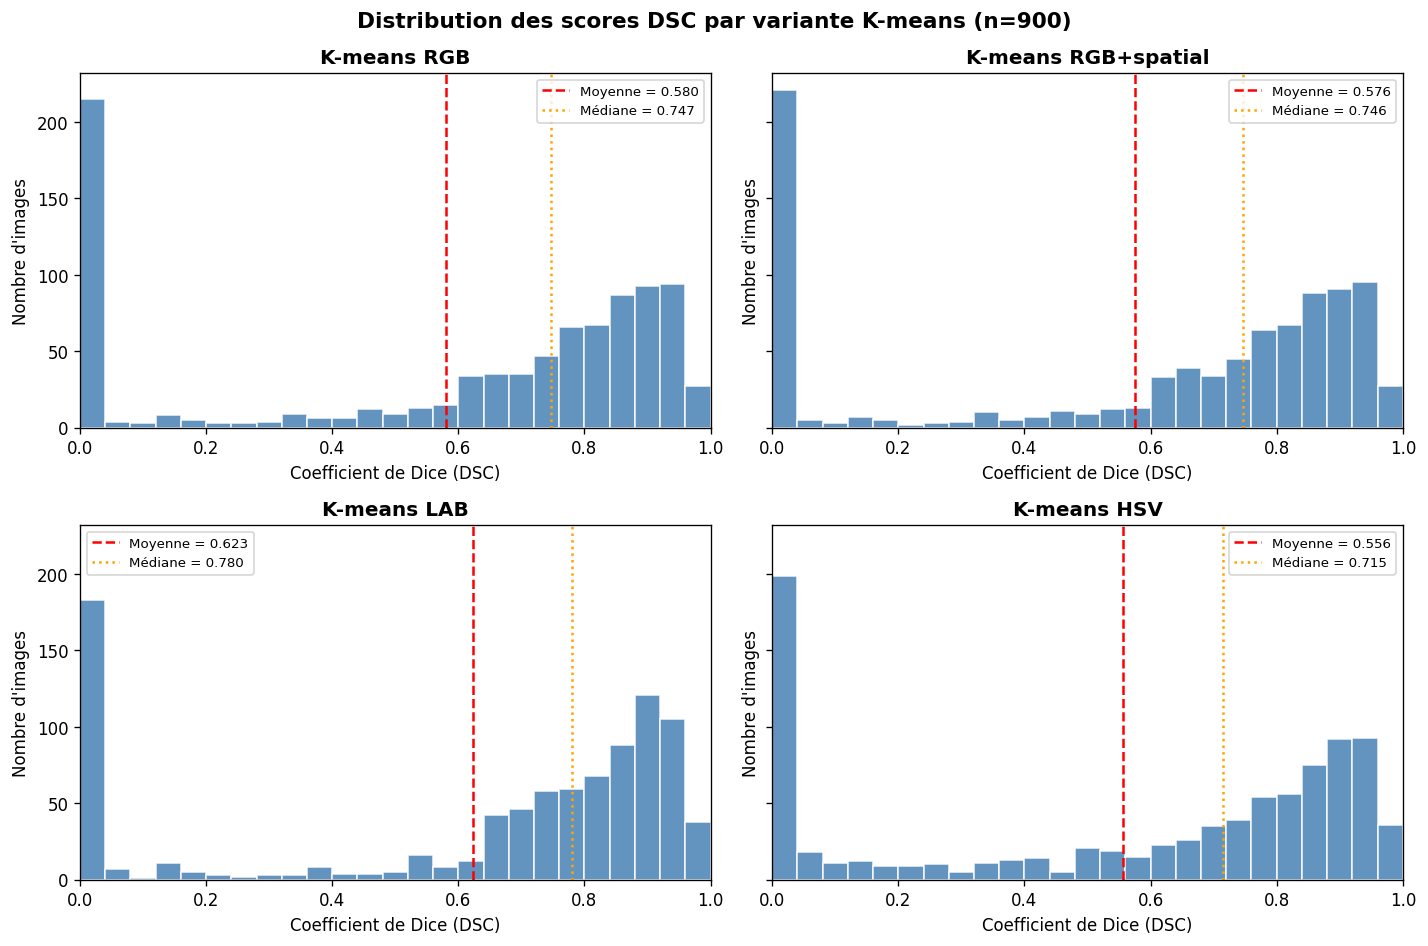

In [9]:
# ═══════════════════════════════════════════════════════════════
# Histogrammes des DSC pour les 4 variantes
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
bins = np.linspace(0, 1, 26)

for ax, (name, df) in zip(axes.ravel(), dfs.items()):
    ax.hist(df["dice"], bins=bins, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(df["dice"].mean(), color="red", linestyle="--", label=f"Moyenne = {df['dice'].mean():.3f}")
    ax.axvline(df["dice"].median(), color="orange", linestyle=":", label=f"Médiane = {df['dice'].median():.3f}")
    ax.set_title(f"K-means {name}", fontweight="bold")
    ax.set_xlabel("Coefficient de Dice (DSC)")
    ax.set_ylabel("Nombre d'images")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

fig.suptitle("Distribution des scores DSC par variante K-means (n=900)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 5. Boxplots comparatifs des 4 variantes

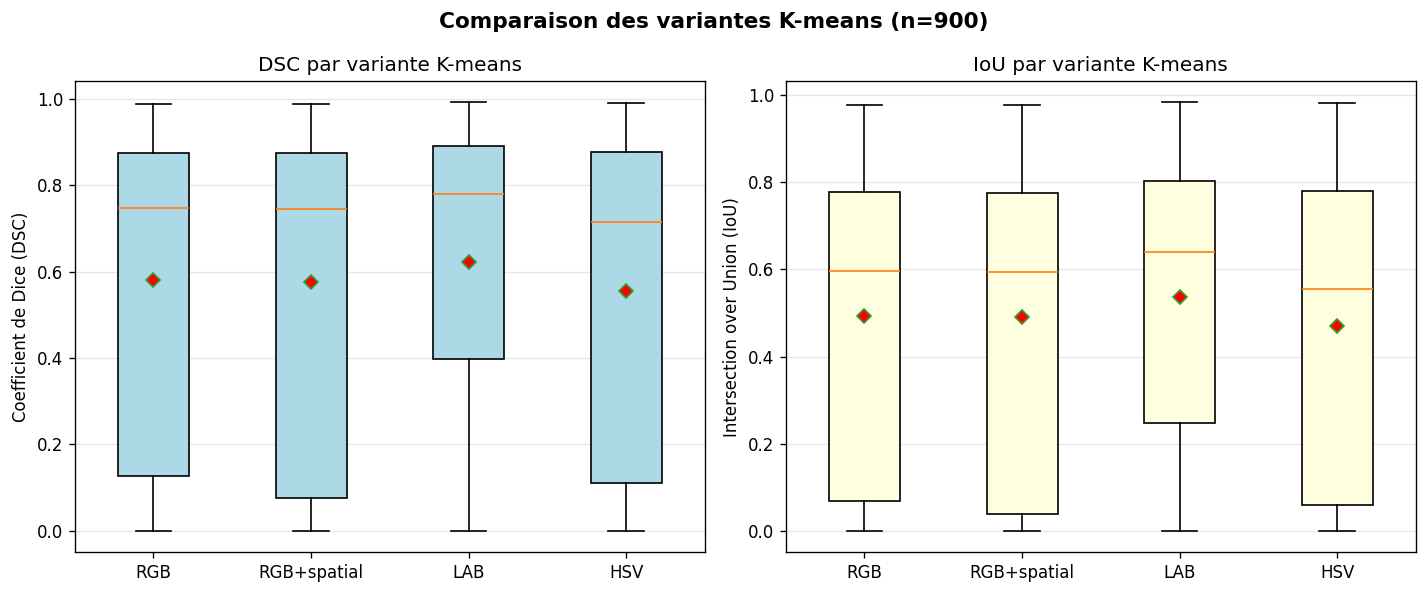

In [10]:
# ═══════════════════════════════════════════════════════════════
# Boxplots comparatifs DSC et IoU
# ═══════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

names = list(dfs.keys())
dice_data = [dfs[n]["dice"].values for n in names]
iou_data = [dfs[n]["iou"].values for n in names]

bp1 = ax1.boxplot(dice_data, labels=names, patch_artist=True, showmeans=True,
                   meanprops=dict(marker="D", markerfacecolor="red", markersize=6))
for patch in bp1["boxes"]:
    patch.set_facecolor("lightblue")
ax1.set_ylabel("Coefficient de Dice (DSC)")
ax1.set_title("DSC par variante K-means")
ax1.grid(axis="y", alpha=0.3)

bp2 = ax2.boxplot(iou_data, labels=names, patch_artist=True, showmeans=True,
                   meanprops=dict(marker="D", markerfacecolor="red", markersize=6))
for patch in bp2["boxes"]:
    patch.set_facecolor("lightyellow")
ax2.set_ylabel("Intersection over Union (IoU)")
ax2.set_title("IoU par variante K-means")
ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Comparaison des variantes K-means (n=900)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 6. Analyse par sous-groupes

### 6.1 Par taille de lésion (ratio $\rho$)

On ventile les résultats selon trois classes de taille de lésion :
- **Petites** : $\rho < 5\%$
- **Moyennes** : $5\% \leq \rho < 10\%$
- **Grandes** : $\rho \geq 10\%$

In [11]:
# ═══════════════════════════════════════════════════════════════
# Analyse par sous-groupes de taille de lésion
# ═══════════════════════════════════════════════════════════════

def size_class(rho):
    if rho < 0.05:
        return "Petites (<5%)"
    elif rho < 0.10:
        return "Moyennes (5-10%)"
    else:
        return "Grandes (>10%)"

size_order = ["Petites (<5%)", "Moyennes (5-10%)", "Grandes (>10%)"]

print("=" * 95)
print(f"{'Variante':<15} {'Sous-groupe':<20} {'n':>4} {'DSC mean±std':>16} {'IoU mean±std':>16} {'Échecs':>8}")
print("=" * 95)

for name, df in dfs.items():
    df["size_class"] = df["rho"].apply(size_class)
    for sc in size_order:
        sub = df[df["size_class"] == sc]
        if len(sub) == 0:
            continue
        n_fail = (sub["dice"] < 0.5).sum()
        print(f"{name:<15} {sc:<20} {len(sub):>4} "
              f"{sub['dice'].mean():.3f} ± {sub['dice'].std():.3f}   "
              f"{sub['iou'].mean():.3f} ± {sub['iou'].std():.3f}   "
              f"{n_fail:>3d}")
    print("─" * 95)

Variante        Sous-groupe             n     DSC mean±std     IoU mean±std   Échecs
RGB             Petites (<5%)          73 0.080 ± 0.232   0.065 ± 0.198    67
RGB             Moyennes (5-10%)      144 0.321 ± 0.405   0.279 ± 0.368    93
RGB             Grandes (>10%)        683 0.688 ± 0.288   0.584 ± 0.277   120
───────────────────────────────────────────────────────────────────────────────────────────────
RGB+spatial     Petites (<5%)          73 0.069 ± 0.219   0.057 ± 0.188    68
RGB+spatial     Moyennes (5-10%)      144 0.310 ± 0.404   0.270 ± 0.368    95
RGB+spatial     Grandes (>10%)        683 0.686 ± 0.291   0.583 ± 0.279   122
───────────────────────────────────────────────────────────────────────────────────────────────
LAB             Petites (<5%)          73 0.146 ± 0.319   0.127 ± 0.284    61
LAB             Moyennes (5-10%)      144 0.370 ± 0.416   0.323 ± 0.381    85
LAB             Grandes (>10%)        683 0.728 ± 0.267   0.625 ± 0.261    90
─────────────────────

### 6.2 Par niveau de contraste $|\Delta|$

On ventile selon le contraste absolu lésion/fond :
- **Faible** : $|\Delta| < 20$
- **Moyen** : $20 \leq |\Delta| < 50$
- **Fort** : $|\Delta| \geq 50$

In [12]:
# ═══════════════════════════════════════════════════════════════
# Analyse par sous-groupes de contraste
# ═══════════════════════════════════════════════════════════════

def contrast_class(delta):
    ad = abs(delta)
    if ad < 20:
        return "Faible (|Δ|<20)"
    elif ad < 50:
        return "Moyen (20≤|Δ|<50)"
    else:
        return "Fort (|Δ|≥50)"

contrast_order = ["Faible (|Δ|<20)", "Moyen (20≤|Δ|<50)", "Fort (|Δ|≥50)"]

print("=" * 95)
print(f"{'Variante':<15} {'Sous-groupe':<22} {'n':>4} {'DSC mean±std':>16} {'IoU mean±std':>16} {'Échecs':>8}")
print("=" * 95)

for name, df in dfs.items():
    df["contrast_class"] = df["delta"].apply(contrast_class)
    for cc in contrast_order:
        sub = df[df["contrast_class"] == cc]
        if len(sub) == 0:
            continue
        n_fail = (sub["dice"] < 0.5).sum()
        print(f"{name:<15} {cc:<22} {len(sub):>4} "
              f"{sub['dice'].mean():.3f} ± {sub['dice'].std():.3f}   "
              f"{sub['iou'].mean():.3f} ± {sub['iou'].std():.3f}   "
              f"{n_fail:>3d}")
    print("─" * 95)

Variante        Sous-groupe               n     DSC mean±std     IoU mean±std   Échecs
RGB             Faible (|Δ|<20)         193 0.254 ± 0.293   0.183 ± 0.224   137
RGB             Moyen (20≤|Δ|<50)       356 0.540 ± 0.357   0.446 ± 0.315   115
RGB             Fort (|Δ|≥50)           351 0.800 ± 0.239   0.713 ± 0.233    28
───────────────────────────────────────────────────────────────────────────────────────────────
RGB+spatial     Faible (|Δ|<20)         193 0.255 ± 0.297   0.184 ± 0.228   137
RGB+spatial     Moyen (20≤|Δ|<50)       356 0.529 ± 0.362   0.437 ± 0.318   120
RGB+spatial     Fort (|Δ|≥50)           351 0.800 ± 0.239   0.713 ± 0.233    28
───────────────────────────────────────────────────────────────────────────────────────────────
LAB             Faible (|Δ|<20)         193 0.338 ± 0.336   0.257 ± 0.270   112
LAB             Moyen (20≤|Δ|<50)       356 0.584 ± 0.355   0.491 ± 0.320   101
LAB             Fort (|Δ|≥50)           351 0.820 ± 0.225   0.736 ± 0.222    23
─

### 6.3 Scatter plot : DSC en fonction de $\rho$ et $|\Delta|$

Permet de visualiser les facteurs de difficulté et d'identifier les cas d'échec.

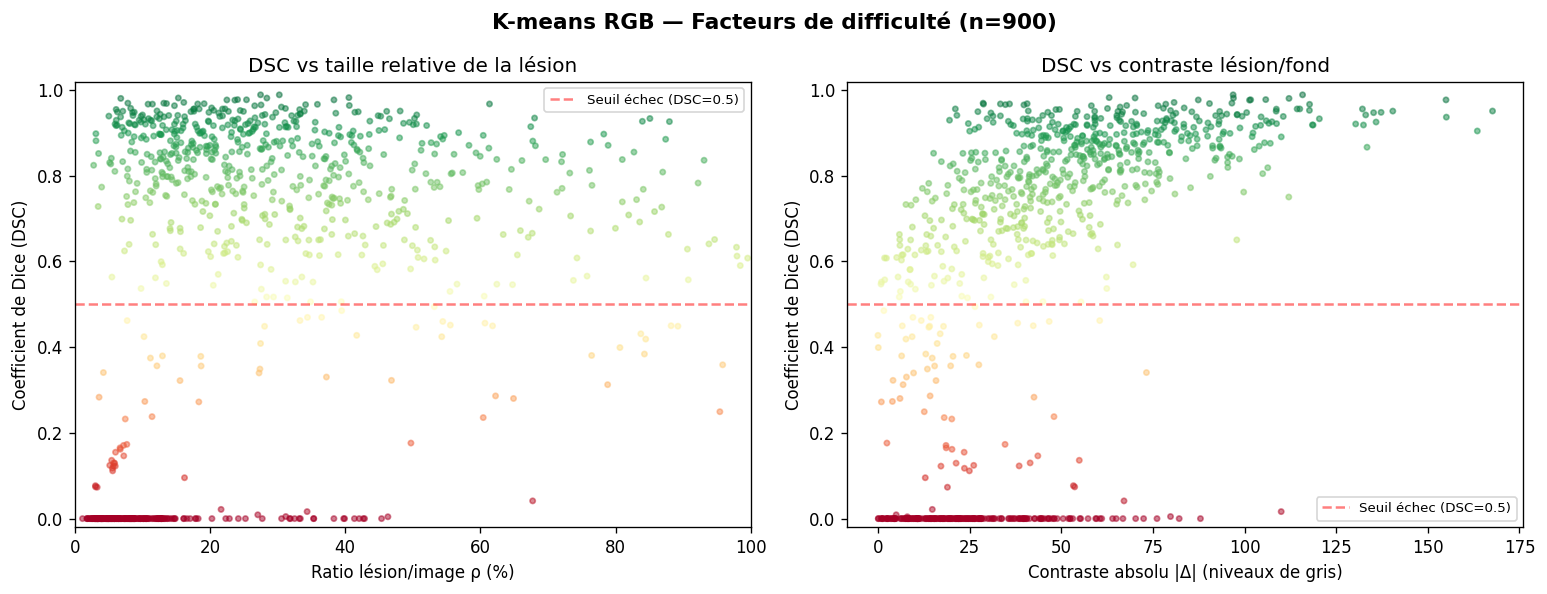

In [13]:
# ═══════════════════════════════════════════════════════════════
# Scatter plots : DSC vs rho et DSC vs |Delta|   (baseline RGB)
# ═══════════════════════════════════════════════════════════════

df_rgb = dfs["RGB"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# DSC vs rho
sc1 = ax1.scatter(df_rgb["rho"] * 100, df_rgb["dice"], s=10, alpha=0.5, c=df_rgb["dice"],
                  cmap="RdYlGn", vmin=0, vmax=1)
ax1.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Seuil échec (DSC=0.5)")
ax1.set_xlabel("Ratio lésion/image ρ (%)")
ax1.set_ylabel("Coefficient de Dice (DSC)")
ax1.set_title("DSC vs taille relative de la lésion")
ax1.legend(fontsize=8)
ax1.set_xlim(0, 100)
ax1.set_ylim(-0.02, 1.02)

# DSC vs |delta|
sc2 = ax2.scatter(np.abs(df_rgb["delta"]), df_rgb["dice"], s=10, alpha=0.5, c=df_rgb["dice"],
                  cmap="RdYlGn", vmin=0, vmax=1)
ax2.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Seuil échec (DSC=0.5)")
ax2.set_xlabel("Contraste absolu |Δ| (niveaux de gris)")
ax2.set_ylabel("Coefficient de Dice (DSC)")
ax2.set_title("DSC vs contraste lésion/fond")
ax2.legend(fontsize=8)
ax2.set_ylim(-0.02, 1.02)

fig.suptitle("K-means RGB — Facteurs de difficulté (n=900)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 7. Diagnostic de l'effet de loupe (vignettage)

L'**effet de loupe** est le facteur d'échec principal du K-means sur les images dermoscopiques. On implémente une heuristique de détection automatique basée sur l'analyse des bords de l'image :
- On calcule l'intensité moyenne d'une **bande périphérique** (5% de la largeur/hauteur sur chaque bord)
- On la compare à l'intensité moyenne de la **zone centrale**
- Si la périphérie est significativement plus sombre (seuil empirique), l'image est classée comme présentant un vignettage

In [14]:
# ═══════════════════════════════════════════════════════════════
# Détection heuristique de l'effet de loupe
# ═══════════════════════════════════════════════════════════════

def detect_vignette(img, border_frac=0.05, threshold=40):
    """
    Détecte le vignettage en comparant l'intensité de la périphérie à celle du centre.
    
    Retourne :
        is_vignette (bool), diff (float) : différence d'intensité centre - périphérie
    """
    gray = 0.299 * img[..., 0].astype(float) + 0.587 * img[..., 1].astype(float) + 0.114 * img[..., 2].astype(float)
    h, w = gray.shape
    bh, bw = max(1, int(h * border_frac)), max(1, int(w * border_frac))
    
    # Masque de la bande périphérique
    border_mask = np.zeros_like(gray, dtype=bool)
    border_mask[:bh, :] = True   # haut
    border_mask[-bh:, :] = True  # bas
    border_mask[:, :bw] = True   # gauche
    border_mask[:, -bw:] = True  # droite
    
    center_mask = ~border_mask
    
    mean_border = gray[border_mask].mean()
    mean_center = gray[center_mask].mean()
    diff = mean_center - mean_border  # positif si périphérie plus sombre
    
    return diff > threshold, diff


# Appliquer à toutes les images
vignette_flags = []
vignette_diffs = []

for i in range(N):
    img = load_img(img_paths[i])
    is_vig, diff = detect_vignette(img)
    vignette_flags.append(is_vig)
    vignette_diffs.append(diff)

n_vignette = sum(vignette_flags)
print(f"Images détectées avec effet de loupe : {n_vignette} / {N} ({100*n_vignette/N:.1f}%)")
print(f"Diff centre-périphérie : mean={np.mean(vignette_diffs):.1f}, "
      f"median={np.median(vignette_diffs):.1f}, max={np.max(vignette_diffs):.1f}")

# Ajouter l'info aux DataFrames
for name, df in dfs.items():
    df["vignette"] = vignette_flags
    df["vignette_diff"] = vignette_diffs

Images détectées avec effet de loupe : 52 / 900 (5.8%)
Diff centre-périphérie : mean=-0.7, median=1.4, max=100.5


In [15]:
# ═══════════════════════════════════════════════════════════════
# Impact du vignettage sur les performances (baseline RGB)
# ═══════════════════════════════════════════════════════════════

df_rgb = dfs["RGB"]

for group_name, mask in [("Sans vignettage", ~df_rgb["vignette"]), ("Avec vignettage", df_rgb["vignette"])]:
    sub = df_rgb[mask]
    if len(sub) == 0:
        continue
    print(f"\n{group_name} (n={len(sub)}) :")
    for col in ["dice", "iou", "accuracy"]:
        print(f"  {col.upper():<10} mean={sub[col].mean():.4f}  std={sub[col].std():.4f}  "
              f"median={sub[col].median():.4f}  min={sub[col].min():.4f}  max={sub[col].max():.4f}")
    print(f"  Échecs (DSC<0.5) : {(sub['dice'] < 0.5).sum()}")

# Comparaison pour toutes les variantes
print("\n" + "=" * 80)
print(f"{'Variante':<15} {'Sans vignette (DSC)':>22} {'Avec vignette (DSC)':>22} {'Δ DSC':>10}")
print("=" * 80)
for name, df in dfs.items():
    no_vig = df[~df["vignette"]]["dice"]
    vig = df[df["vignette"]]["dice"]
    if len(vig) > 0 and len(no_vig) > 0:
        print(f"{name:<15} {no_vig.mean():.3f} ± {no_vig.std():.3f} (n={len(no_vig)})   "
              f"{vig.mean():.3f} ± {vig.std():.3f} (n={len(vig)})   "
              f"{vig.mean() - no_vig.mean():>+.3f}")


Sans vignettage (n=848) :
  DICE       mean=0.6058  std=0.3520  median=0.7618  min=0.0000  max=0.9889
  IOU        mean=0.5154  std=0.3247  median=0.6153  min=0.0000  max=0.9781
  ACCURACY   mean=0.8352  std=0.1616  median=0.8800  min=0.1046  max=0.9973
  Échecs (DSC<0.5) : 238

Avec vignettage (n=52) :
  DICE       mean=0.1625  std=0.3202  median=0.0000  min=0.0000  max=0.9170
  IOU        mean=0.1348  std=0.2724  median=0.0000  min=0.0000  max=0.8468
  ACCURACY   mean=0.6903  std=0.2310  median=0.7878  min=0.1170  max=0.9828
  Échecs (DSC<0.5) : 42

Variante           Sans vignette (DSC)    Avec vignette (DSC)      Δ DSC
RGB             0.606 ± 0.352 (n=848)   0.162 ± 0.320 (n=52)   -0.443
RGB+spatial     0.601 ± 0.356 (n=848)   0.162 ± 0.320 (n=52)   -0.439
LAB             0.650 ± 0.339 (n=848)   0.180 ± 0.335 (n=52)   -0.470
HSV             0.573 ± 0.360 (n=848)   0.278 ± 0.370 (n=52)   -0.296


## 8. Visualisations qualitatives

On sélectionne automatiquement des cas représentatifs de trois régimes de performance pour le K-means RGB :
1. **Cas favorable** : meilleur DSC parmi les images sans vignettage
2. **Cas intermédiaire** : DSC autour de 0.5-0.6 (vignettage modéré)
3. **Cas d'échec** : pire DSC (vignettage sévère)

Pour chaque cas, on affiche : image originale, masque K-means, ground truth, carte de différence.

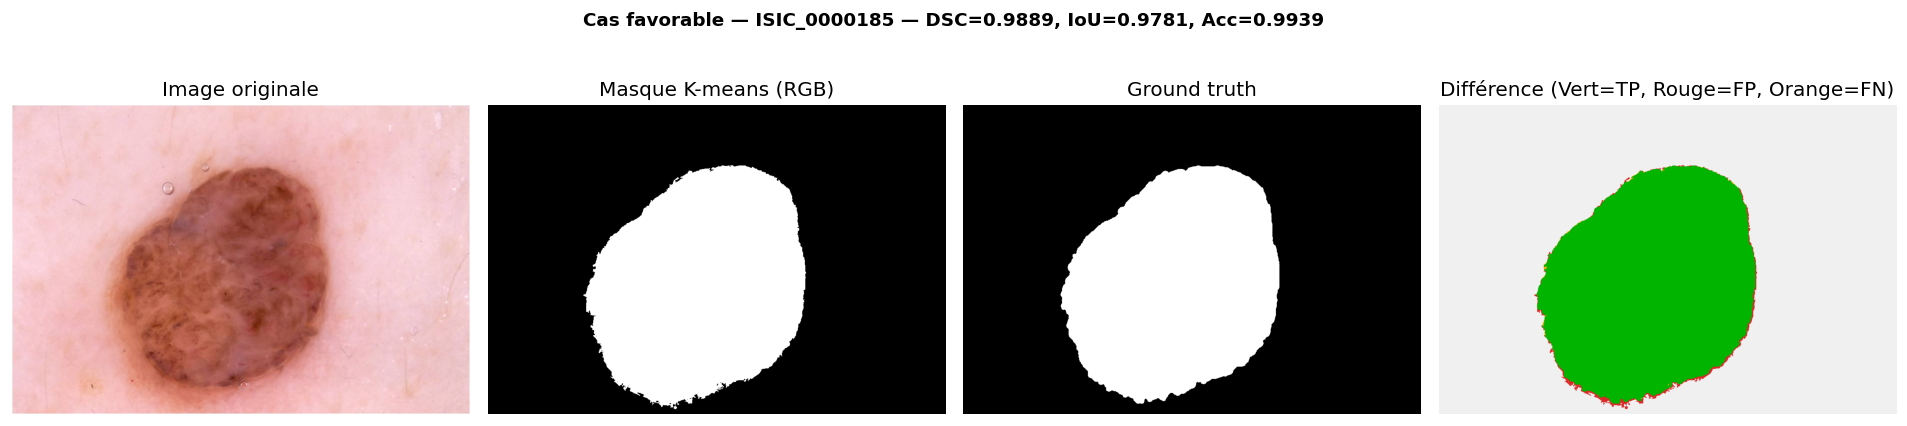

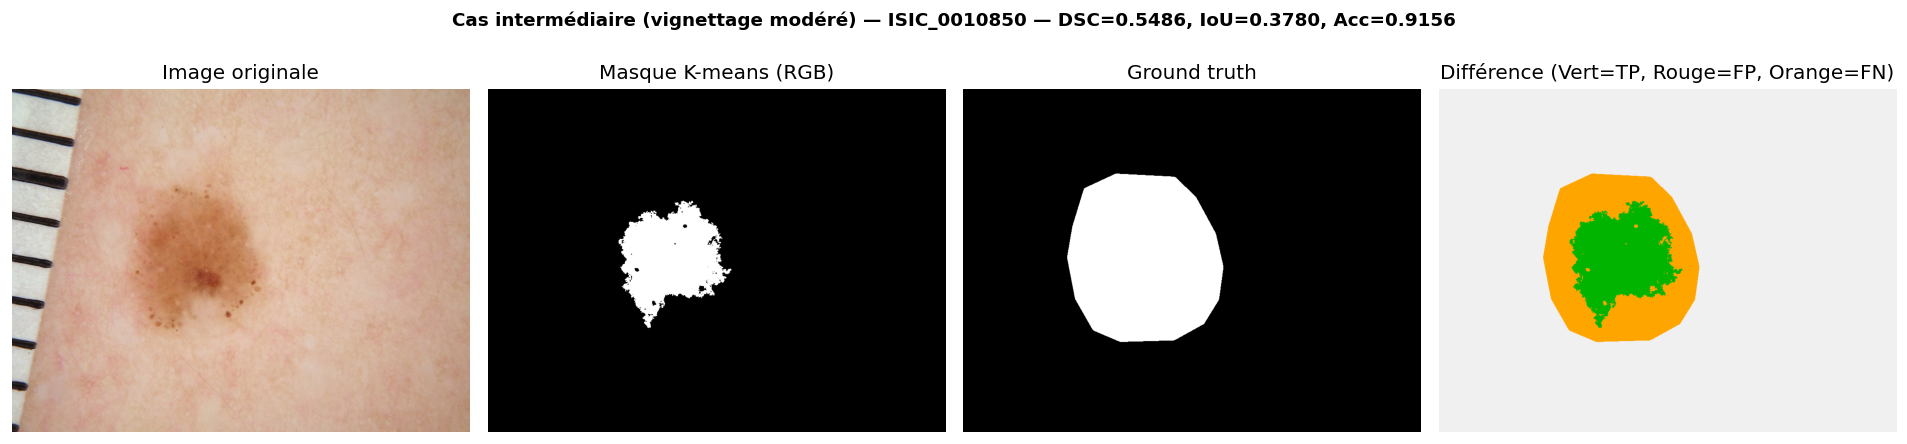

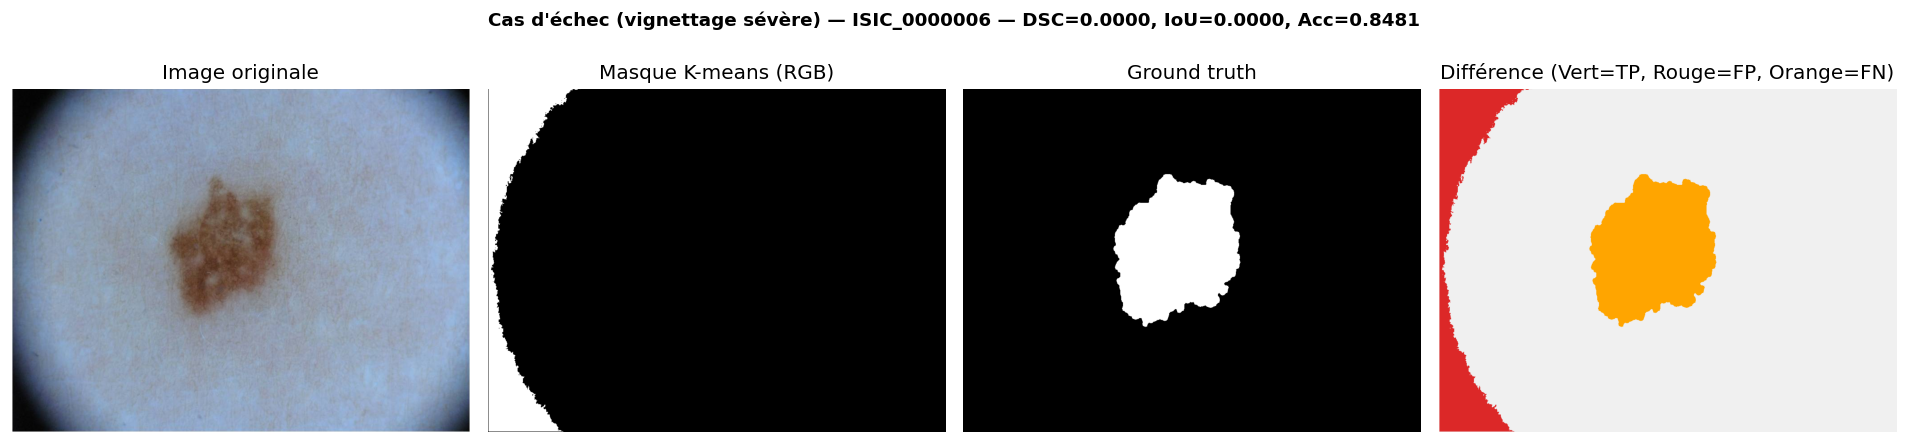

In [16]:
# ═══════════════════════════════════════════════════════════════
# Visualisations qualitatives : 3 régimes de performance
# ═══════════════════════════════════════════════════════════════

df_rgb = dfs["RGB"].copy()

# Sélection des 3 cas
idx_best = df_rgb["dice"].idxmax()
idx_worst = df_rgb["dice"].idxmin()
# Cas intermédiaire : DSC le plus proche de 0.55
idx_mid = (df_rgb["dice"] - 0.55).abs().idxmin()

cases = [
    ("Cas favorable", idx_best),
    ("Cas intermédiaire (vignettage modéré)", idx_mid),
    ("Cas d'échec (vignettage sévère)", idx_worst),
]

for title, idx in cases:
    row = df_rgb.iloc[idx]
    img_path = img_paths[idx]
    mask_path = mask_paths[idx]
    
    img = load_img(img_path)
    gt = load_mask(mask_path)
    pred = segment_kmeans_rgb(img)
    
    # Carte de différence : vert = TP, rouge = erreur (FP ou FN)
    diff_map = np.zeros((*gt.shape, 3), dtype=np.uint8)
    diff_map[(gt == 1) & (pred == 1)] = [0, 180, 0]     # TP = vert
    diff_map[(gt == 0) & (pred == 1)] = [220, 40, 40]    # FP = rouge
    diff_map[(gt == 1) & (pred == 0)] = [255, 165, 0]    # FN = orange
    diff_map[(gt == 0) & (pred == 0)] = [240, 240, 240]  # TN = gris clair
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(img)
    axes[0].set_title("Image originale")
    
    axes[1].imshow(pred, cmap="gray")
    axes[1].set_title("Masque K-means (RGB)")
    
    axes[2].imshow(gt, cmap="gray")
    axes[2].set_title("Ground truth")
    
    axes[3].imshow(diff_map)
    axes[3].set_title("Différence (Vert=TP, Rouge=FP, Orange=FN)")
    
    for ax in axes:
        ax.axis("off")
    
    fig.suptitle(f"{title} — {row['image']} — DSC={row['dice']:.4f}, IoU={row['iou']:.4f}, Acc={row['accuracy']:.4f}",
                 fontsize=11, fontweight="bold")
    fig.tight_layout()
    plt.show()

## 9. Comparaison des 4 variantes sur les cas d'échec

On compare visuellement le comportement des 4 variantes sur les images les plus difficiles (les 5 pires DSC en RGB).

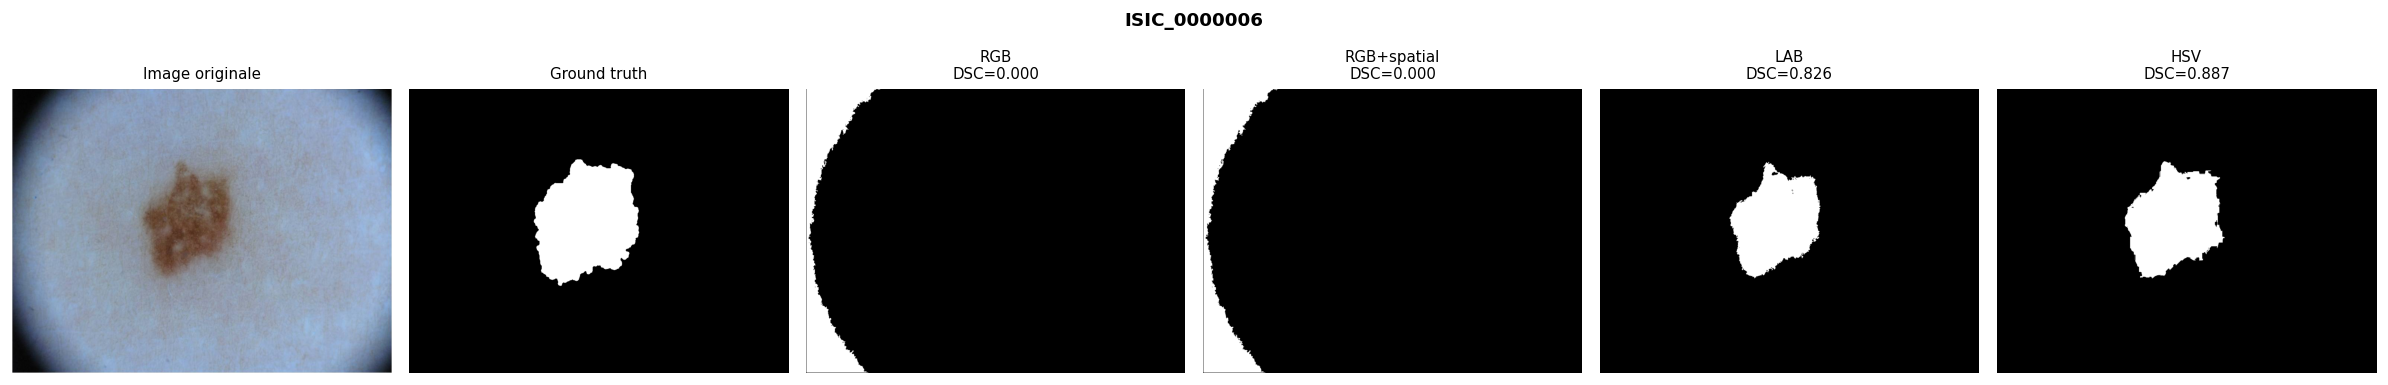

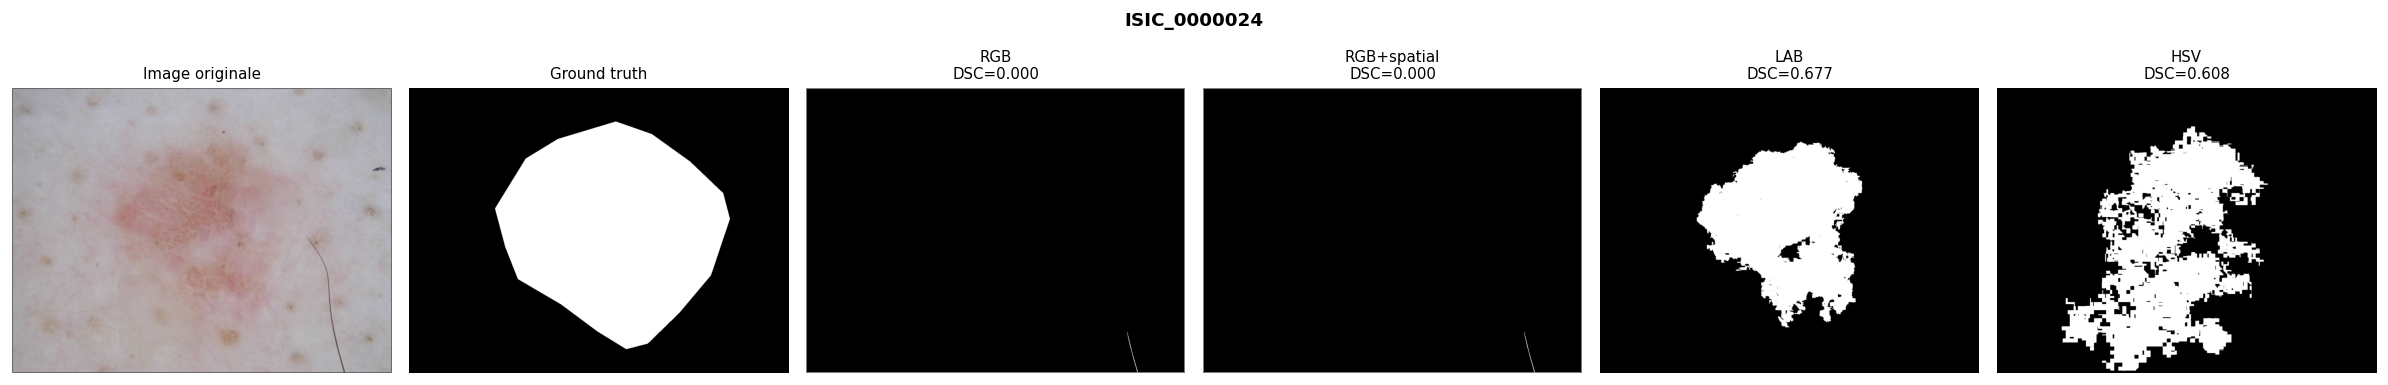

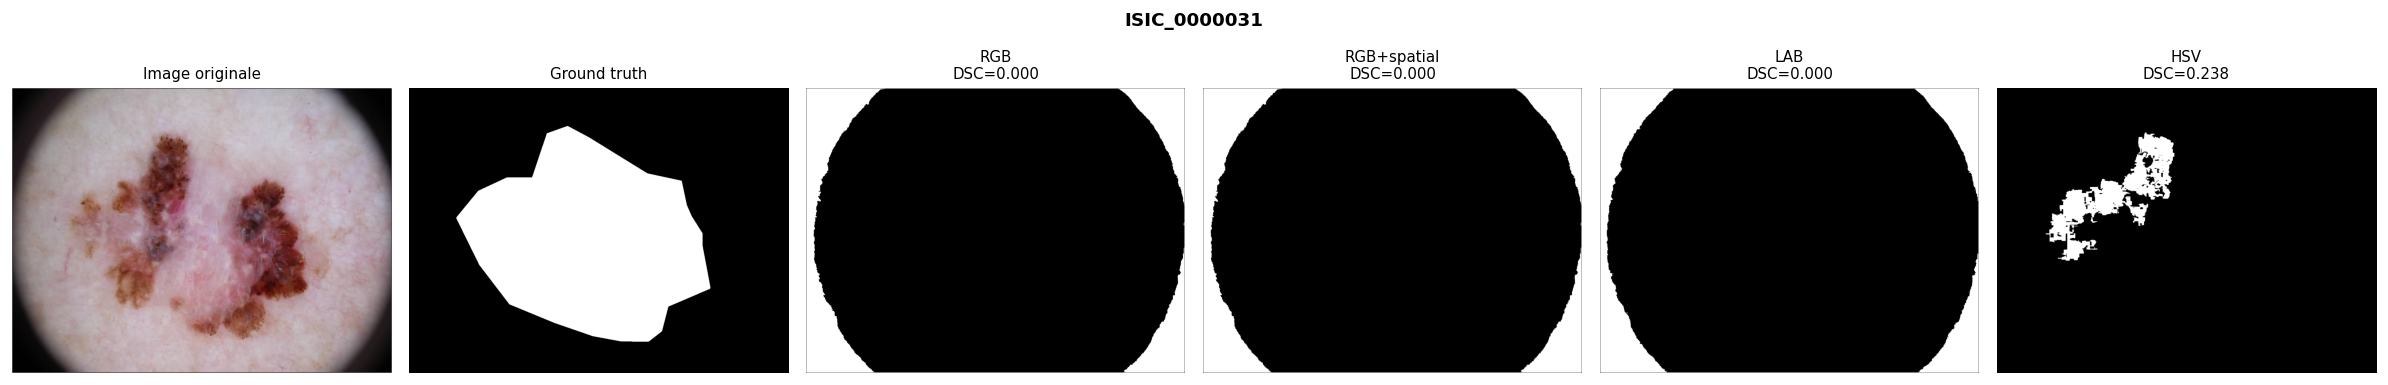

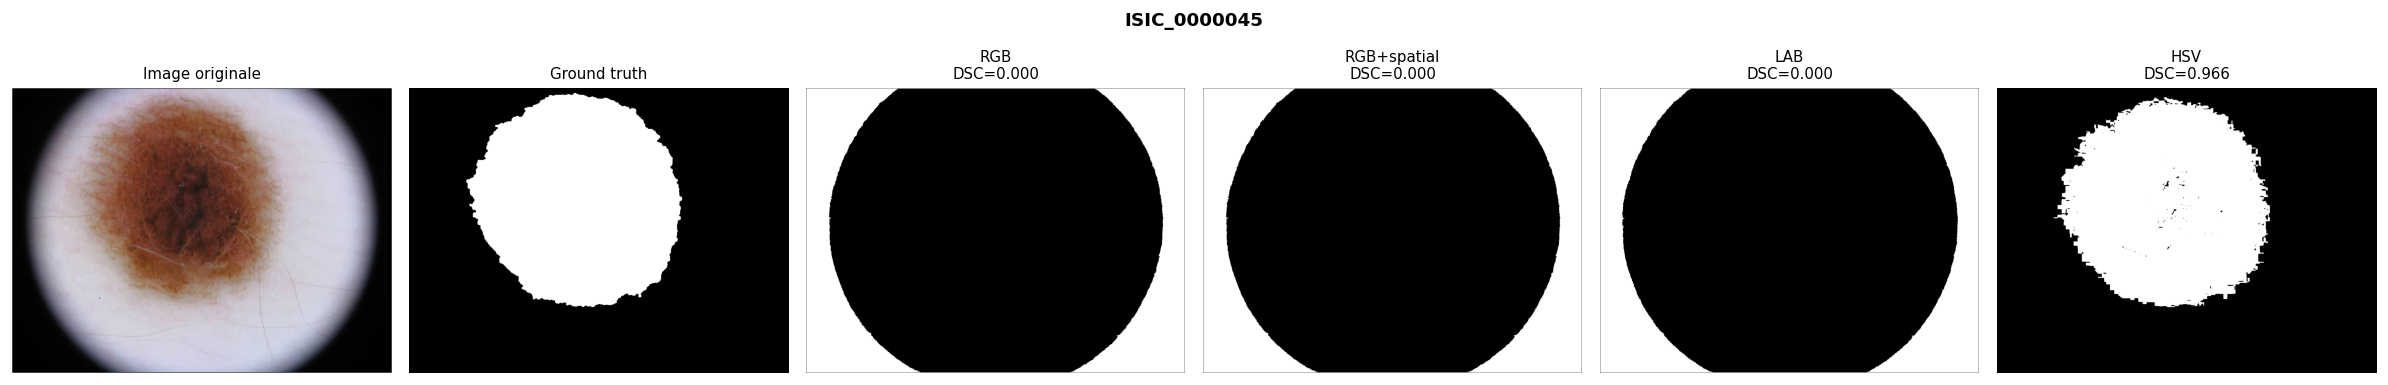

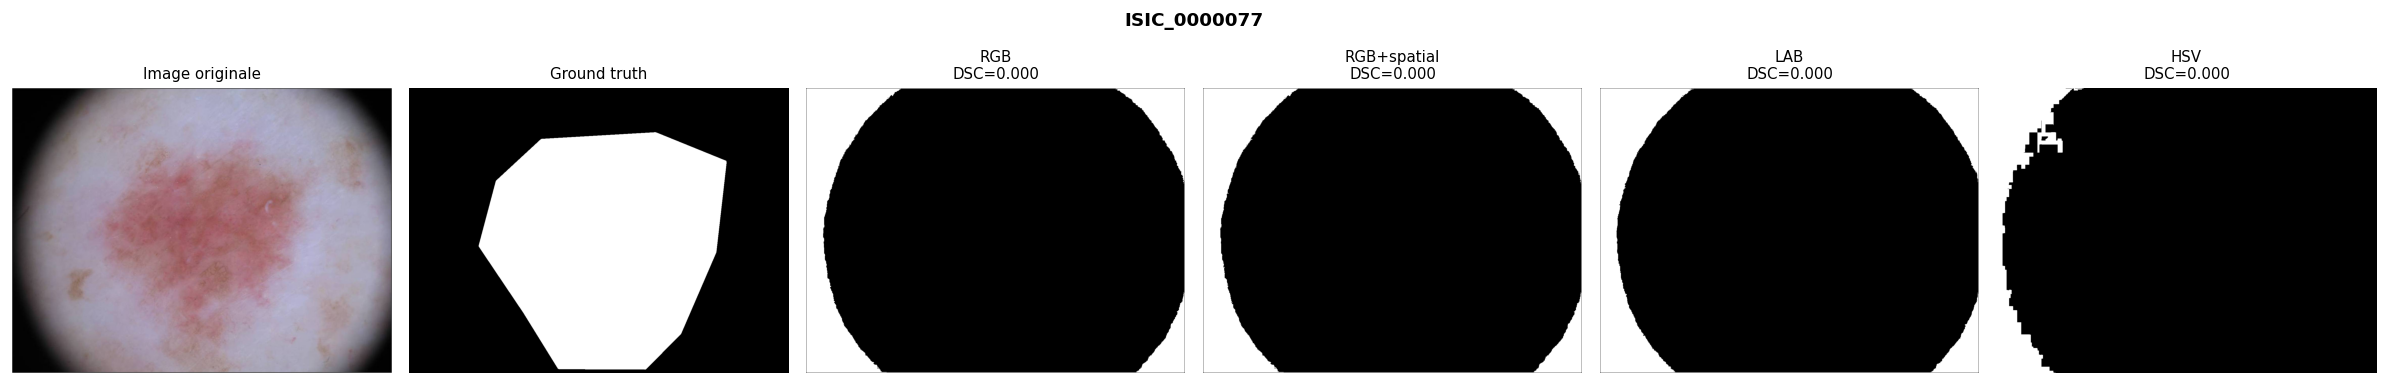

In [17]:
# ═══════════════════════════════════════════════════════════════
# Comparaison des 4 variantes sur les 5 pires cas (RGB)
# ═══════════════════════════════════════════════════════════════

df_rgb = dfs["RGB"]
worst5_idx = df_rgb["dice"].nsmallest(5).index.tolist()

method_fns = list(METHODS.items())

for idx in worst5_idx:
    img = load_img(img_paths[idx])
    gt = load_mask(mask_paths[idx])
    stem = img_paths[idx].stem
    
    fig, axes = plt.subplots(1, 6, figsize=(20, 3.5))
    
    axes[0].imshow(img)
    axes[0].set_title("Image originale", fontsize=9)
    axes[0].axis("off")
    
    axes[1].imshow(gt, cmap="gray")
    axes[1].set_title("Ground truth", fontsize=9)
    axes[1].axis("off")
    
    for j, (mname, mfn) in enumerate(method_fns):
        pred = mfn(img)
        d = dice(gt, pred)
        axes[j + 2].imshow(pred, cmap="gray")
        axes[j + 2].set_title(f"{mname}\nDSC={d:.3f}", fontsize=9)
        axes[j + 2].axis("off")
    
    fig.suptitle(f"{stem}", fontsize=11, fontweight="bold")
    fig.tight_layout()
    plt.show()

## 10. Corrélation DSC entre variantes — Les variantes corrigent-elles les échecs ?

On analyse si les variantes alternatives (LAB, HSV, RGB+spatial) améliorent significativement les images où le RGB échoue.

In [18]:
# ═══════════════════════════════════════════════════════════════
# Corrélation entre variantes et analyse des cas où RGB échoue
# ═══════════════════════════════════════════════════════════════

# Construire un DataFrame avec les DSC de chaque variante côte à côte
df_compare = pd.DataFrame({
    name: df["dice"].values for name, df in dfs.items()
})
df_compare.index = dfs["RGB"]["image"].values

# Matrice de corrélation
print("Matrice de corrélation des DSC entre variantes :")
print(df_compare.corr().round(3))

# Analyse sur les échecs RGB (DSC < 0.5)
rgb_failures = df_compare[df_compare["RGB"] < 0.5]
print(f"\n--- Images en échec pour RGB (DSC < 0.5) : n={len(rgb_failures)} ---")
if len(rgb_failures) > 0:
    print("\nDSC moyen des autres variantes sur ces images :")
    for col in df_compare.columns:
        print(f"  {col:<15} mean={rgb_failures[col].mean():.3f}  "
              f"median={rgb_failures[col].median():.3f}  "
              f"max={rgb_failures[col].max():.3f}")
    
    # Combien sont sauvées par chaque variante ?
    for col in ["LAB", "HSV", "RGB+spatial"]:
        saved = (rgb_failures[col] >= 0.5).sum()
        print(f"\n  {col} sauve {saved}/{len(rgb_failures)} cas d'échec RGB "
              f"(DSC >= 0.5 dans {100*saved/len(rgb_failures):.0f}% des cas)")

Matrice de corrélation des DSC entre variantes :
               RGB  RGB+spatial    LAB    HSV
RGB          1.000        0.986  0.875  0.646
RGB+spatial  0.986        1.000  0.862  0.639
LAB          0.875        0.862  1.000  0.681
HSV          0.646        0.639  0.681  1.000

--- Images en échec pour RGB (DSC < 0.5) : n=280 ---

DSC moyen des autres variantes sur ces images :
  RGB             mean=0.070  median=0.000  max=0.494
  RGB+spatial     mean=0.067  median=0.000  max=0.495
  LAB             mean=0.191  median=0.000  max=0.968
  HSV             mean=0.221  median=0.000  max=0.983

  LAB sauve 54/280 cas d'échec RGB (DSC >= 0.5 dans 19% des cas)

  HSV sauve 64/280 cas d'échec RGB (DSC >= 0.5 dans 23% des cas)

  RGB+spatial sauve 0/280 cas d'échec RGB (DSC >= 0.5 dans 0% des cas)


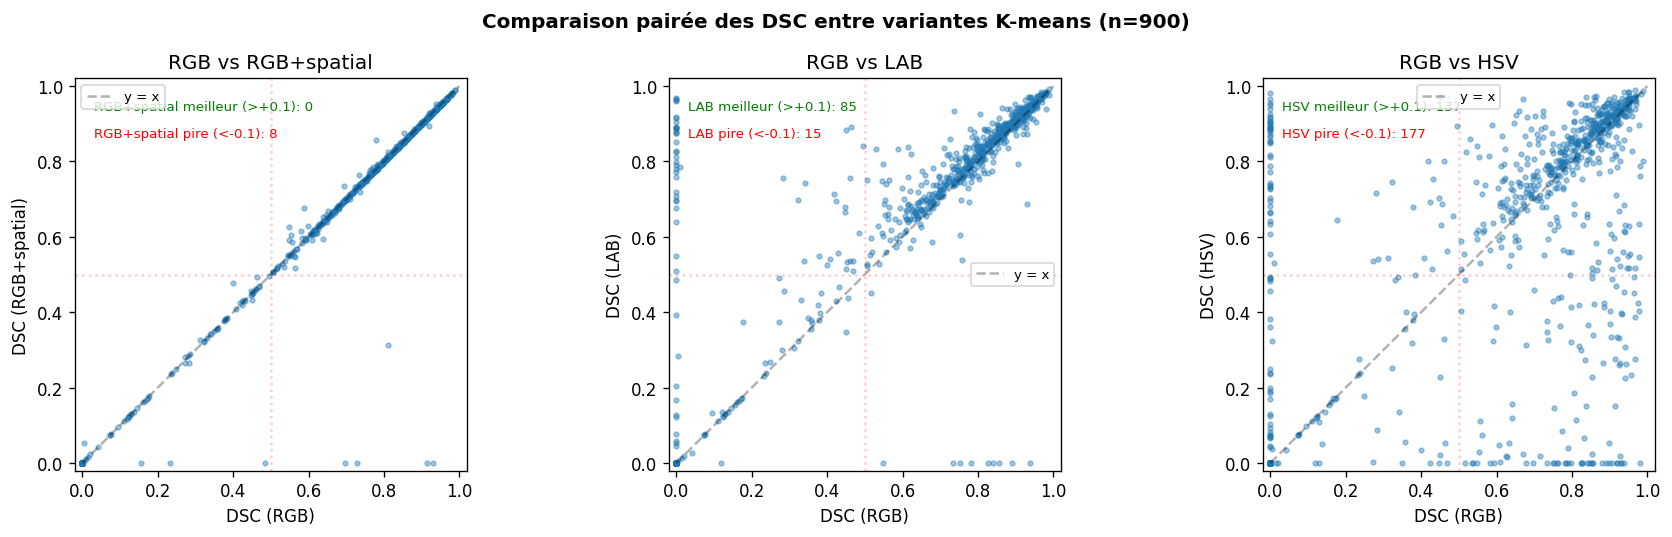

In [19]:
# ═══════════════════════════════════════════════════════════════
# Scatter plots pairés : DSC RGB vs DSC des autres variantes
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
alt_names = ["RGB+spatial", "LAB", "HSV"]

for ax, alt in zip(axes, alt_names):
    ax.scatter(df_compare["RGB"], df_compare[alt], s=8, alpha=0.4)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="y = x")
    ax.axhline(0.5, color="red", alpha=0.2, linestyle=":")
    ax.axvline(0.5, color="red", alpha=0.2, linestyle=":")
    ax.set_xlabel("DSC (RGB)")
    ax.set_ylabel(f"DSC ({alt})")
    ax.set_title(f"RGB vs {alt}")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect("equal")
    ax.legend(fontsize=8)
    
    # Annoter les points au-dessus de la diagonale
    better = (df_compare[alt] > df_compare["RGB"] + 0.1).sum()
    worse = (df_compare[alt] < df_compare["RGB"] - 0.1).sum()
    ax.text(0.05, 0.92, f"{alt} meilleur (>+0.1): {better}", transform=ax.transAxes, fontsize=8, color="green")
    ax.text(0.05, 0.85, f"{alt} pire (<-0.1): {worse}", transform=ax.transAxes, fontsize=8, color="red")

fig.suptitle("Comparaison pairée des DSC entre variantes K-means (n=900)", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

## 11. Analyse d'erreur détaillée — Precision vs Recall

L'analyse du couple **precision/recall** permet de comprendre le type d'erreur dominant :
- **Faible precision, bon recall** → sur-segmentation (trop de faux positifs)
- **Bonne precision, faible recall** → sous-segmentation (contours trop conservateurs)
- L'effet de loupe devrait se manifester par une chute de precision (les pixels de bordure sont des FP massifs)

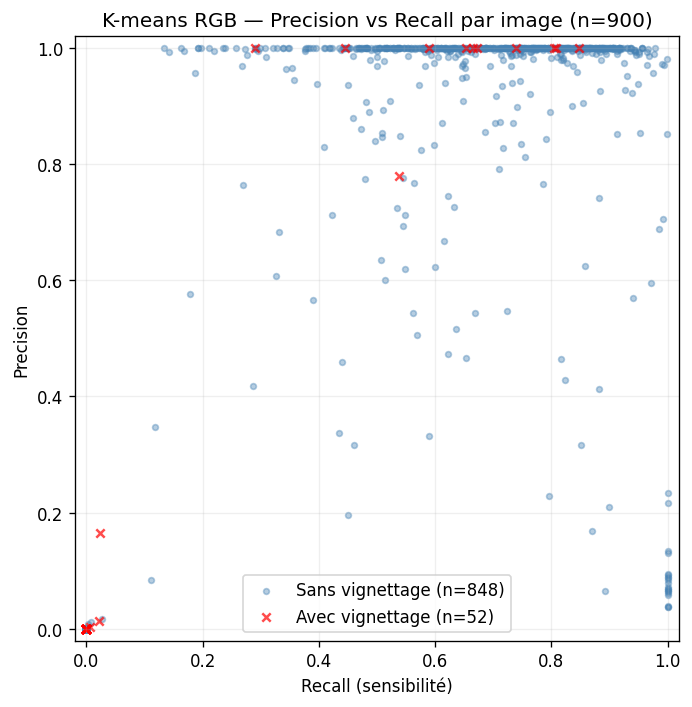

K-means RGB — Precision et Recall :
  Global :     Precision = 0.706 ± 0.432   Recall = 0.530 ± 0.340
  Vignettage : Precision = 0.211 ± 0.404   Recall = 0.137 ± 0.274
  Sans vig. :  Precision = 0.737 ± 0.415   Recall = 0.555 ± 0.328


In [20]:
# ═══════════════════════════════════════════════════════════════
# Scatter Precision vs Recall (baseline RGB), coloré par vignettage
# ═══════════════════════════════════════════════════════════════

df_rgb = dfs["RGB"]

fig, ax = plt.subplots(figsize=(7, 6))

no_vig = df_rgb[~df_rgb["vignette"]]
vig = df_rgb[df_rgb["vignette"]]

ax.scatter(no_vig["recall"], no_vig["precision"], s=12, alpha=0.4, color="steelblue", label=f"Sans vignettage (n={len(no_vig)})")
ax.scatter(vig["recall"], vig["precision"], s=25, alpha=0.7, color="red", marker="x", label=f"Avec vignettage (n={len(vig)})")

ax.set_xlabel("Recall (sensibilité)")
ax.set_ylabel("Precision")
ax.set_title("K-means RGB — Precision vs Recall par image (n=900)")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.legend()
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()

# Stats precision/recall
print("K-means RGB — Precision et Recall :")
print(f"  Global :     Precision = {df_rgb['precision'].mean():.3f} ± {df_rgb['precision'].std():.3f}   "
      f"Recall = {df_rgb['recall'].mean():.3f} ± {df_rgb['recall'].std():.3f}")
if len(vig) > 0:
    print(f"  Vignettage : Precision = {vig['precision'].mean():.3f} ± {vig['precision'].std():.3f}   "
          f"Recall = {vig['recall'].mean():.3f} ± {vig['recall'].std():.3f}")
print(f"  Sans vig. :  Precision = {no_vig['precision'].mean():.3f} ± {no_vig['precision'].std():.3f}   "
      f"Recall = {no_vig['recall'].mean():.3f} ± {no_vig['recall'].std():.3f}")

## 12. Test statistique : Wilcoxon signed-rank test entre variantes

Pour valider que les différences observées entre variantes sont significatives, on effectue un test de Wilcoxon apparié (test non paramétrique adapté aux distributions non normales des DSC).

In [21]:
# ═══════════════════════════════════════════════════════════════
# Tests de Wilcoxon apparié : RGB vs chaque variante
# ═══════════════════════════════════════════════════════════════

from scipy.stats import wilcoxon

ref = dfs["RGB"]["dice"].values

print("Test de Wilcoxon apparié — H0 : pas de différence de DSC médian avec RGB")
print("=" * 75)
print(f"{'Comparaison':<25} {'Δ DSC moyen':>12} {'Δ DSC médian':>13} {'Statistique':>12} {'p-value':>12}")
print("=" * 75)

for name in ["RGB+spatial", "LAB", "HSV"]:
    alt = dfs[name]["dice"].values
    diff = alt - ref
    stat, p = wilcoxon(diff, alternative="two-sided")
    print(f"RGB vs {name:<18} {diff.mean():>+.4f}      {np.median(diff):>+.4f}       {stat:>10.0f}   {p:>11.2e}  "
          f"{'***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'}")

print("\nSignificativité : *** p<0.001, ** p<0.01, * p<0.05, n.s. non significatif")

Test de Wilcoxon apparié — H0 : pas de différence de DSC médian avec RGB
Comparaison                Δ DSC moyen  Δ DSC médian  Statistique      p-value
RGB vs RGB+spatial        -0.0042      +0.0000            78418      4.54e-13  ***
RGB vs LAB                +0.0430      +0.0090            40298      3.30e-60  ***
RGB vs HSV                -0.0240      +0.0003           133393      7.34e-02  n.s.

Significativité : *** p<0.001, ** p<0.01, * p<0.05, n.s. non significatif


## 13. Tableau récapitulatif final — Prêt pour le mémoire

Synthèse de toutes les métriques dans un format directement transposable en LaTeX.

In [22]:
# ═══════════════════════════════════════════════════════════════
# Tableau récapitulatif pour le mémoire (format LaTeX)
# ═══════════════════════════════════════════════════════════════

print("% ── Tableau LaTeX : Comparaison des variantes K-means ──")
print(r"\begin{table}[H]")
print(r"\centering")
print(r"\caption{Résultats comparatifs des variantes K-means sur ISIC~2016 ($n = 900$).}")
print(r"\label{tab:kmeans_comparison}")
print(r"\small")
print(r"\begin{tabular}{l r r r r r r}")
print(r"\toprule")
print(r"\textbf{Variante} & \textbf{DSC} & \textbf{IoU} & \textbf{Accuracy} & \textbf{Precision} & \textbf{Recall} & \textbf{Échecs} \\")
print(r"\midrule")

for name, df in dfs.items():
    n_fail = (df["dice"] < 0.5).sum()
    line = f"{name} & "
    for col in ["dice", "iou", "accuracy", "precision", "recall"]:
        line += f"${df[col].mean():.3f} \\pm {df[col].std():.3f}$ & "
    line += f"{n_fail} ({100*n_fail/len(df):.1f}\\%) \\\\"
    print(line)

print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table}")

print("\n\n% ── Tableau LaTeX : K-means RGB par sous-groupe de taille ──")
print(r"\begin{table}[H]")
print(r"\centering")
print(r"\caption{K-means RGB --- Performances par sous-groupe de taille de lésion.}")
print(r"\label{tab:kmeans_subgroups}")
print(r"\begin{tabular}{l r r r r}")
print(r"\toprule")
print(r"\textbf{Sous-groupe} & \textbf{$n$} & \textbf{DSC} & \textbf{IoU} & \textbf{Échecs (DSC$<$0.5)} \\")
print(r"\midrule")

df_rgb = dfs["RGB"]
for sc in size_order:
    sub = df_rgb[df_rgb["size_class"] == sc]
    n_fail = (sub["dice"] < 0.5).sum()
    print(f"{sc} & {len(sub)} & ${sub['dice'].mean():.3f} \\pm {sub['dice'].std():.3f}$ "
          f"& ${sub['iou'].mean():.3f} \\pm {sub['iou'].std():.3f}$ & {n_fail} \\\\")

print(r"\midrule")
print(f"Total & {len(df_rgb)} & ${df_rgb['dice'].mean():.3f} \\pm {df_rgb['dice'].std():.3f}$ "
      f"& ${df_rgb['iou'].mean():.3f} \\pm {df_rgb['iou'].std():.3f}$ & {(df_rgb['dice'] < 0.5).sum()} \\\\")
print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table}")

% ── Tableau LaTeX : Comparaison des variantes K-means ──
\begin{table}[H]
\centering
\caption{Résultats comparatifs des variantes K-means sur ISIC~2016 ($n = 900$).}
\label{tab:kmeans_comparison}
\small
\begin{tabular}{l r r r r r r}
\toprule
\textbf{Variante} & \textbf{DSC} & \textbf{IoU} & \textbf{Accuracy} & \textbf{Precision} & \textbf{Recall} & \textbf{Échecs} \\
\midrule
RGB & $0.580 \pm 0.365$ & $0.493 \pm 0.334$ & $0.827 \pm 0.170$ & $0.706 \pm 0.432$ & $0.530 \pm 0.340$ & 280 (31.1\%) \\
RGB+spatial & $0.576 \pm 0.368$ & $0.490 \pm 0.336$ & $0.825 \pm 0.169$ & $0.698 \pm 0.435$ & $0.527 \pm 0.342$ & 285 (31.7\%) \\
LAB & $0.623 \pm 0.356$ & $0.537 \pm 0.329$ & $0.839 \pm 0.173$ & $0.745 \pm 0.416$ & $0.576 \pm 0.331$ & 236 (26.2\%) \\
HSV & $0.556 \pm 0.367$ & $0.471 \pm 0.340$ & $0.783 \pm 0.220$ & $0.647 \pm 0.425$ & $0.596 \pm 0.374$ & 327 (36.3\%) \\
\bottomrule
\end{tabular}
\end{table}


% ── Tableau LaTeX : K-means RGB par sous-groupe de taille ──
\begin{table}[H]
\cen

## 14. Sauvegarde des résultats en JSON

Export de tous les résultats par image pour exploitation ultérieure (comparaison avec U-Net, etc.).

In [23]:
# ═══════════════════════════════════════════════════════════════
# Sauvegarde des résultats
# ═══════════════════════════════════════════════════════════════

import json

output = {}
for name, df in dfs.items():
    # Convertir les booléens numpy en Python natif pour la sérialisation
    records = df.to_dict(orient="records")
    for r in records:
        for k, v in r.items():
            if isinstance(v, (np.bool_,)):
                r[k] = bool(v)
            elif isinstance(v, (np.integer,)):
                r[k] = int(v)
            elif isinstance(v, (np.floating,)):
                r[k] = float(v)
    
    agg = {}
    for col in metrics_cols:
        agg[col] = {
            "mean": round(float(df[col].mean()), 4),
            "std": round(float(df[col].std()), 4),
            "median": round(float(df[col].median()), 4),
            "q1": round(float(df[col].quantile(0.25)), 4),
            "q3": round(float(df[col].quantile(0.75)), 4),
            "min": round(float(df[col].min()), 4),
            "max": round(float(df[col].max()), 4),
        }
    agg["n"] = len(df)
    agg["n_failures_dsc05"] = int((df["dice"] < 0.5).sum())
    
    output[name] = {"aggregate": agg, "per_image": records}

out_path = BASE / "results_kmeans.json"
with open(out_path, "w") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(f"Résultats sauvegardés dans : {out_path}")
print(f"Taille du fichier : {out_path.stat().st_size / 1024:.0f} Ko")

Résultats sauvegardés dans : /Users/sfarmehdi/Stat_app/statapp/results_kmeans.json
Taille du fichier : 1599 Ko


## 15. Synthèse et conclusions pour le mémoire

### Résultats clés attendus

1. **K-means RGB (baseline)** : DSC moyen autour de 0.7-0.8, avec une forte variance due à l'effet de loupe. Distribution bimodale des DSC.

2. **Effet de loupe** : facteur d'échec principal, détectable par l'analyse de l'intensité périphérique. Les images avec vignettage ont un DSC significativement inférieur.

3. **Variantes** :
   - **RGB + coordonnées spatiales** : amélioration potentielle en favorisant la compacité spatiale des clusters
   - **LAB** : espace perceptuellement uniforme, potentiellement plus robuste aux variations d'éclairage
   - **HSV** : séparation chrominance/luminance, peut aider pour les lésions hypopigmentées

4. **Analyse par sous-groupes** : les petites lésions (ρ < 5%) et les images à faible contraste (|Δ| < 20) sont les cas les plus difficiles.

5. **Limites structurelles** du K-means : absence de modélisation spatiale, sensibilité aux conditions d'acquisition, hypothèse de clusters sphériques. Ces limites motivent le passage à l'apprentissage profond (U-Net).

---

## 16. Statistiques géométriques du dataset — Centroïdes et résolutions

Calcul des valeurs manquantes pour les tableaux du mémoire :
- Écart-types des positions normalisées des centroïdes de lésion ($x/W$, $y/H$)
- Distance en pixels du centroïde au centre de l'image
- Nombre et liste des résolutions distinctes dans le dataset

In [24]:
# ═══════════════════════════════════════════════════════════════
# Statistiques des centroïdes et résolutions du dataset
# ═══════════════════════════════════════════════════════════════

x_norms = []
y_norms = []
distances_px = []
resolutions = set()

# Résolutions des images
for img_path in img_paths:
    img = Image.open(img_path)
    w, h = img.size
    resolutions.add((w, h))

# Centroïdes des lésions (à partir des masques)
for mask_path in mask_paths:
    m = np.array(Image.open(mask_path).convert("L"))
    m_bin = (m > 127).astype(np.uint8)
    h, w = m_bin.shape

    # Plus grande composante connexe
    labeled, n_comp = ndimage.label(m_bin)
    if n_comp == 0:
        continue
    sizes = ndimage.sum(m_bin, labeled, range(1, n_comp + 1))
    largest = np.argmax(sizes) + 1
    largest_mask = (labeled == largest).astype(np.uint8)

    # Centroïde
    cy, cx = ndimage.center_of_mass(largest_mask)
    x_norms.append(cx / w)
    y_norms.append(cy / h)

    # Distance au centre en pixels
    dist = np.sqrt((cx - w / 2)**2 + (cy - h / 2)**2)
    distances_px.append(dist)

x_norms = np.array(x_norms)
y_norms = np.array(y_norms)
distances_px = np.array(distances_px)

# ── Affichage ──
print("=" * 60)
print("STATISTIQUES GÉOMÉTRIQUES DU DATASET")
print("=" * 60)

print("\nCentroïdes (coordonnées normalisées) :")
for var_name, arr in [("x/W", x_norms), ("y/H", y_norms)]:
    print(f"  {var_name} : {np.mean(arr):.3f} ± {np.std(arr):.3f}  "
          f"médiane={np.median(arr):.3f}  [{np.min(arr):.3f}, {np.max(arr):.3f}]")

print(f"\nDistance centroïde → centre (px) :")
print(f"  {np.mean(distances_px):.2f} ± {np.std(distances_px):.2f}  "
      f"médiane={np.median(distances_px):.2f}  [{np.min(distances_px):.2f}, {np.max(distances_px):.2f}]")

print(f"\nRésolutions distinctes : {len(resolutions)}")
for res in sorted(resolutions):
    print(f"  {res[0]}×{res[1]}")

# ── Sauvegarde JSON ──
centroid_results = {
    "centroid_stats": {
        "x_norm": {"mean": round(float(np.mean(x_norms)), 3), "std": round(float(np.std(x_norms)), 3),
                   "median": round(float(np.median(x_norms)), 3), "min": round(float(np.min(x_norms)), 3),
                   "max": round(float(np.max(x_norms)), 3)},
        "y_norm": {"mean": round(float(np.mean(y_norms)), 3), "std": round(float(np.std(y_norms)), 3),
                   "median": round(float(np.median(y_norms)), 3), "min": round(float(np.min(y_norms)), 3),
                   "max": round(float(np.max(y_norms)), 3)},
        "distance_px": {"mean": round(float(np.mean(distances_px)), 2), "std": round(float(np.std(distances_px)), 2),
                        "median": round(float(np.median(distances_px)), 2), "min": round(float(np.min(distances_px)), 2),
                        "max": round(float(np.max(distances_px)), 2)},
    },
    "n_distinct_resolutions": len(resolutions),
    "resolutions": sorted([f"{w}x{h}" for w, h in resolutions]),
}

with open(BASE / "results_centroid_stats.json", "w") as f:
    json.dump(centroid_results, f, indent=2, ensure_ascii=False)
print(f"\nSauvegardé dans : {BASE / 'results_centroid_stats.json'}")

STATISTIQUES GÉOMÉTRIQUES DU DATASET

Centroïdes (coordonnées normalisées) :
  x/W : 0.484 ± 0.061  médiane=0.490  [0.195, 0.807]
  y/H : 0.499 ± 0.056  médiane=0.501  [0.237, 0.690]

Distance centroïde → centre (px) :
  109.50 ± 162.66  médiane=52.05  [1.98, 1239.19]

Résolutions distinctes : 74
  576×768
  679×566
  718×542
  722×542
  722×543
  722×545
  724×542
  767×576
  771×750
  796×682
  824×719
  833×680
  838×614
  853×680
  919×802
  944×1127
  949×626
  957×640
  957×723
  958×642
  959×634
  959×638
  960×645
  962×641
  962×671
  962×674
  962×722
  963×629
  964×640
  964×720
  965×624
  965×649
  965×724
  966×638
  1008×711
  1019×717
  1022×767
  1024×768
  1028×753
  1045×705
  1057×704
  1057×707
  1062×701
  1064×702
  1079×705
  1456×1018
  1502×1016
  1502×1026
  1502×1043
  1502×1051
  1503×1129
  1504×1129
  1936×1296
  1936×1936
  2012×1956
  2048×1536
  2101×1943
  2117×1988
  2272×1704
  2283×1824
  2313×1985
  2314×2067
  2565×2000
  2583×2096
  2592×1944
